In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 236 (delta 17), reused 24 (delta 14), pack-reused 204 (from 1)
Receiving objects: 100% (236/236), 1.75 MiB | 14.53 MiB/s, done.
Resolving deltas: 100% (112/112), done.
/content/miniml


In [7]:
from miniml.probability.nbmultinomial import NBMultinominalClassifier

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# 1. Генерация мультиномиальных данных (счетчики частот)
np.random.seed(42)
n_samples = 400
n_features = 40
n_classes = 3

# Распределение Дирихле задает профили классов (как часто каждое слово встречается в теме)
true_word_profiles = np.random.dirichlet(np.ones(n_features) * 0.5, size=n_classes)
y = np.random.choice(n_classes, size=n_samples)

X = np.zeros((n_samples, n_features))
for i in range(n_samples):
    doc_length = np.random.randint(20, 100) # длина "документа" в словах
    X[i] = np.random.multinomial(doc_length, true_word_profiles[y[i]])

# 2. Обучение моделей
alpha_val = 1.0
custom_mnb = NBMultinominalClassifier().fit(X, y, alpha=alpha_val)
sk_mnb = MultinomialNB(alpha=alpha_val).fit(X, y)

# 3. Предикты
custom_preds = custom_mnb.predict(X, use_logarithm=True)
sk_preds = sk_mnb.predict(X)

# ВАЖНО: транспонируем вывод predict_proba, чтобы он совпал с форматом (n_samples, n_classes) в sklearn
custom_probs = custom_mnb.predict_proba(X, use_logarithm=True).T
sk_probs = sk_mnb.predict_proba(X)

# 4. Проверка метрик
acc_custom = accuracy_score(y, custom_preds)
acc_sk = accuracy_score(y, sk_preds)
match_percentage = np.mean(custom_preds == sk_preds) * 100

print("=" * 70)
print("СВОДКА ТЕСТИРОВАНИЯ (MULTINOMIAL NAIVE BAYES)")
print("=" * 70)
print(f"Accuracy (Твой класс): {acc_custom:.4f}")
print(f"Accuracy (Sklearn):    {acc_sk:.4f}")
print(f"Идентичность предсказанных классов: {match_percentage:.1f}%")

# 5. Жесткий Assert на вероятности
max_prob_diff = np.max(np.abs(custom_probs - sk_probs))
print(f"Максимальная дельта в вероятностях: {max_prob_diff:.2e}")
print("=" * 70)

assert np.allclose(custom_probs, sk_probs, atol=1e-5), "Ошибка математики: вычисленные вероятности не совпадают!"

СВОДКА ТЕСТИРОВАНИЯ (MULTINOMIAL NAIVE BAYES)
Accuracy (Твой класс): 1.0000
Accuracy (Sklearn):    1.0000
Идентичность предсказанных классов: 100.0%
Максимальная дельта в вероятностях: 4.88e-15


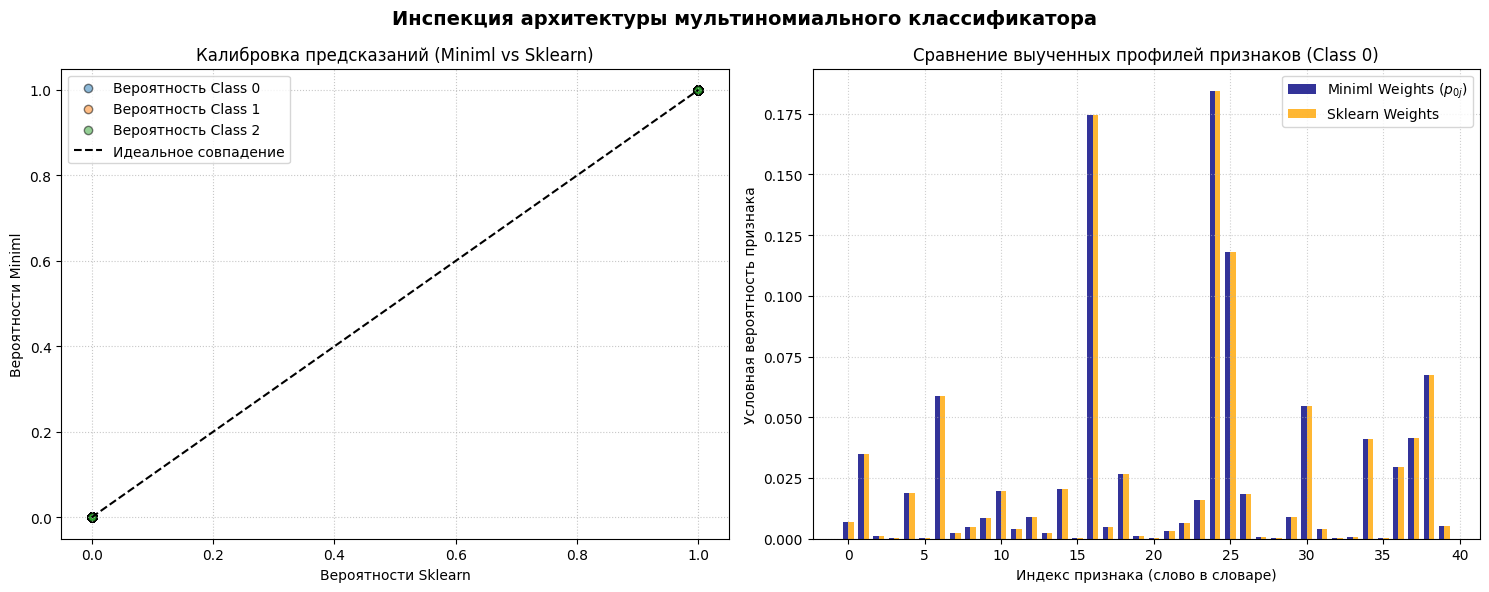

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# График 1: Калибровка предсказанных вероятностей
plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for cl in range(n_classes):
    plt.scatter(
        sk_probs[:, cl],
        custom_probs[:, cl],
        color=colors[cl],
        alpha=0.5,
        edgecolors='k',
        label=f"Вероятность Class {cl}"
    )

# Диагональ идеального совпадения
ideal_line = np.linspace(0, 1, 100)
plt.plot(ideal_line, ideal_line, color='black', linestyle='--', label='Идеальное совпадение')
plt.title("Калибровка предсказаний (Miniml vs Sklearn)")
plt.xlabel("Вероятности Sklearn")
plt.ylabel("Вероятности Miniml")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# График 2: Сопоставление выученных условных вероятностей признаков (для Class 0)
plt.subplot(1, 2, 2)
# Твои веса хранятся линейно
my_weights = custom_mnb.p_y_per_feature[0]
# Веса sklearn хранятся в логарифмах, нужно взять экспоненту
sk_weights = np.exp(sk_mnb.feature_log_prob_[0])

x_indices = np.arange(n_features)
width = 0.35

plt.bar(x_indices - width/2, my_weights, width, label='Miniml Weights ($p_{0j}$)', color='navy', alpha=0.8)
plt.bar(x_indices + width/2, sk_weights, width, label='Sklearn Weights', color='orange', alpha=0.8)
plt.title("Сравнение выученных профилей признаков (Class 0)")
plt.xlabel("Индекс признака (слово в словаре)")
plt.ylabel("Условная вероятность признака")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.suptitle("Инспекция архитектуры мультиномиального классификатора", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()